### Initialize the Environment:
##### Virtual Environment Commands

| Command | Linux/Mac | GitBash |
| ------- | --------- | ------- |
| Create | `python3 -m venv venv` | `python -m venv venv` |
| Activate | `source venv/bin/activate` | `source venv/Scripts/activate` |
| Install | `pip install -r requirements.txt` | `pip install -r requirements.txt` |
| Deactivate | `deactivate` | `deactivate` |
##### Select the Kernel (This will be in the Requirements.txt eventually)

Using the venv (Python 3.13.2) located  in venv/bin/python)

### **Analysis of the Data**
Capstone Project for Code:You Data Analysis track. This project analyzes Beer Recipes for frequency of uploads for various beer styles, while capturing preferences of strength, hopiness and batch size.    The goal of the project is to demonstrate a general knowledge of Python (Pandas, Numpy, MatLibPlot, Plotly), SQL(MySQL), Tableu, Cursor and ChatGPT.


In [1]:
# pip install openpyxl
# %pip install matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import random

In [3]:
# Un-pickle the dataframes from Beer_capstone.ipynb
beer_recipes = pd.read_pickle("cleaned_beer_recipes.pkl")
bjcp_style = pd.read_pickle("cleaned_styles_2021.pkl")

In [4]:
# Confirm that data successfully transferred from Beer_capstone.ipynb
print(beer_recipes.info)
print(bjcp_style.info)

<bound method DataFrame.info of                                      Recipe Name                Style  \
0             Avg. Perfect Northeast IPA (NEIPA)             Hazy IPA   
1                   Sierra Nevada Pale Ale Clone    American Pale Ale   
2                              Vanilla Cream Ale            Cream Ale   
3                  Zombie Dust Clone - ALL GRAIN         American IPA   
4       Russian River Pliny The Elder (original)           Double IPA   
...                                          ...                  ...   
236774                                Mild (110)            Dark Mild   
236775                          Simcoe Mild (99)            Dark Mild   
236776         Malted Bliss, Wedding Barley Wine  English Barley Wine   
236777         Malted Bliss, Wedding Barley Wine  English Barley Wine   
236778                   More LPANE Goodness APA    American Pale Ale   

       Style Number     OG  Plato     FG    ABV     IBU Source  \
0               21C  1.06

In [5]:
# Checking combined data for adherence to the 116 Styles in the BJCP 2021 Style Guide
grouped_style = beer_recipes.groupby('Style Number')

grouped_styles = grouped_style.size()
print(grouped_styles)

Style Number
10A    5967
10B    1064
10C     610
11A    2047
11B    2248
       ... 
8A     1024
8B      916
9A      902
9B       57
9C     1056
Length: 115, dtype: int64


### **Data Visualization**

Chart 1: The distribution of the Beer Recipe Styles among the 116 styles. *Highlighting the top 2 styles because of their dominance*.

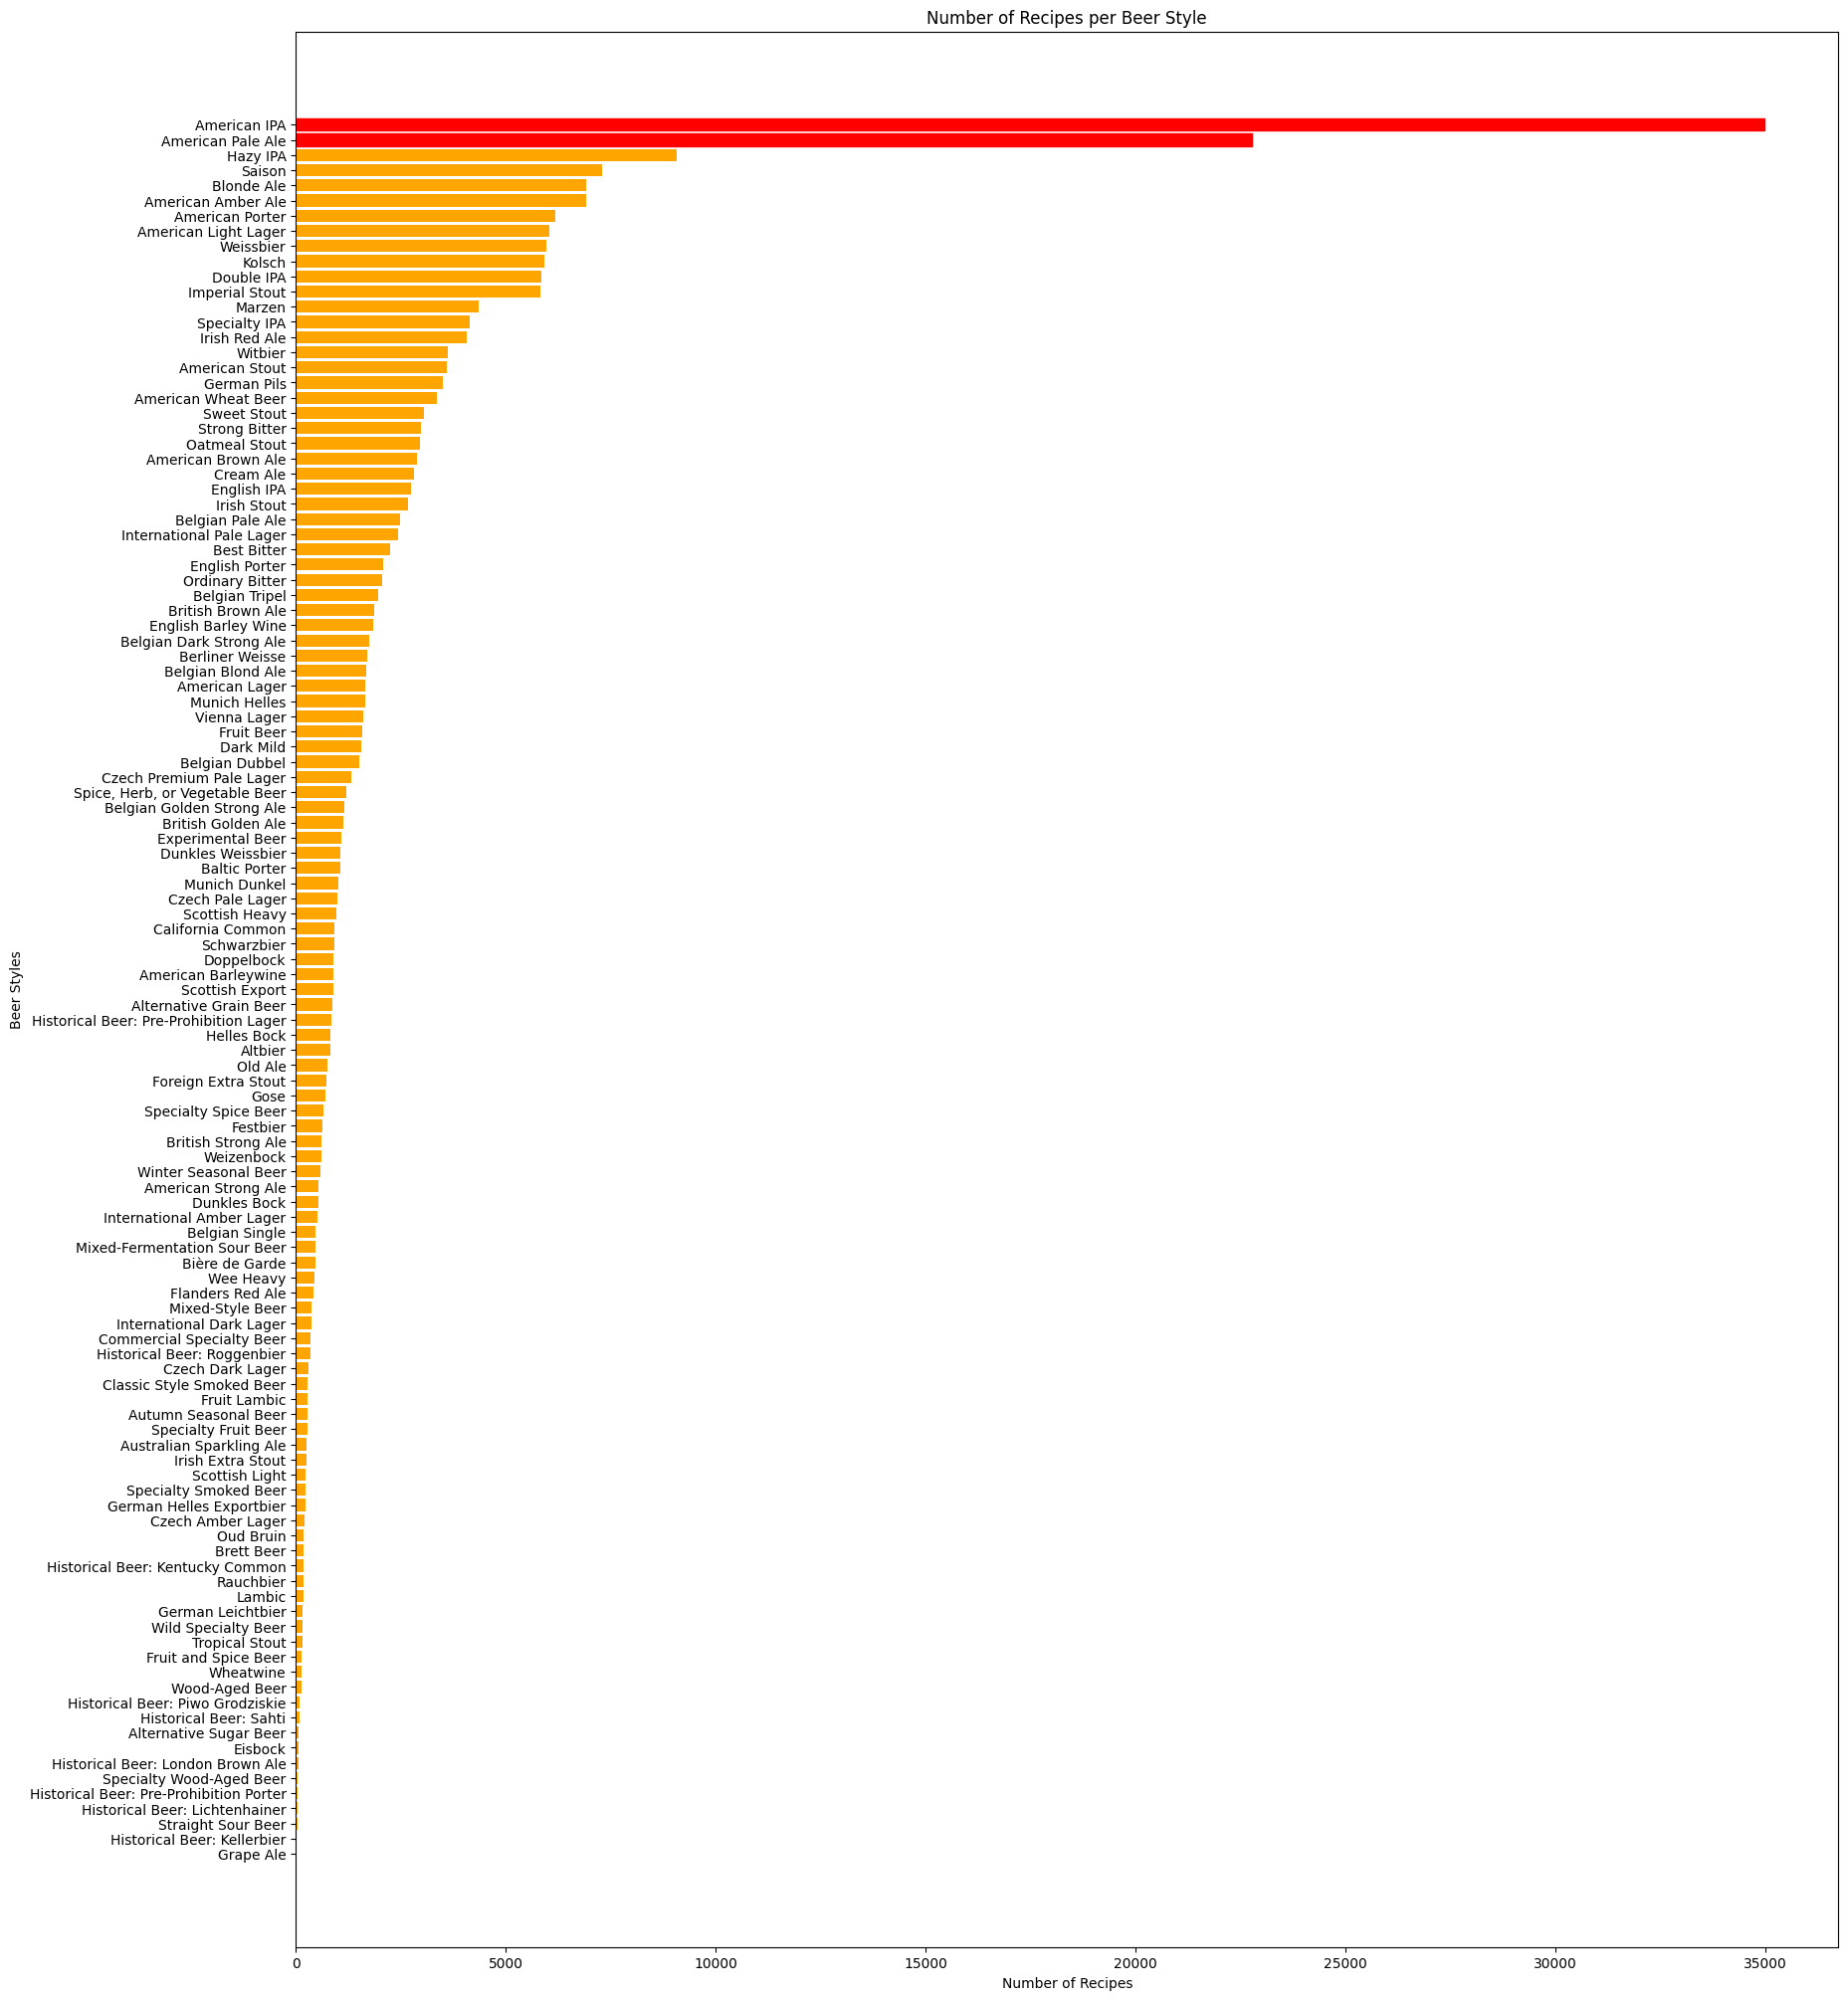

In [6]:
def total_occurrence():
    # Group by 'Style' and count the number of occurrences
    style_counts = beer_recipes['Style'].value_counts()

    # Sort the data in descending order
    style_counts = style_counts.sort_values(ascending=False)
    
    # Plot the bar chart horizontally
    fig, ax = plt.subplots(figsize=(20, 25))
    bars = ax.barh(style_counts.index, style_counts.values, color='orange') # type: ignore

    # Highlight the top 2 bars
    bars[0].set_color('red')
    bars[1].set_color('red')

    plt.xlabel('Number of Recipes')
    plt.ylabel('Beer Styles')
    plt.title('Number of Recipes per Beer Style')
    # Reverse the y-axis to have the largest bars at the top
    ax.invert_yaxis()
    plt.show()

total_occurrence()

Chart 2: The **Top 50** beer styles.

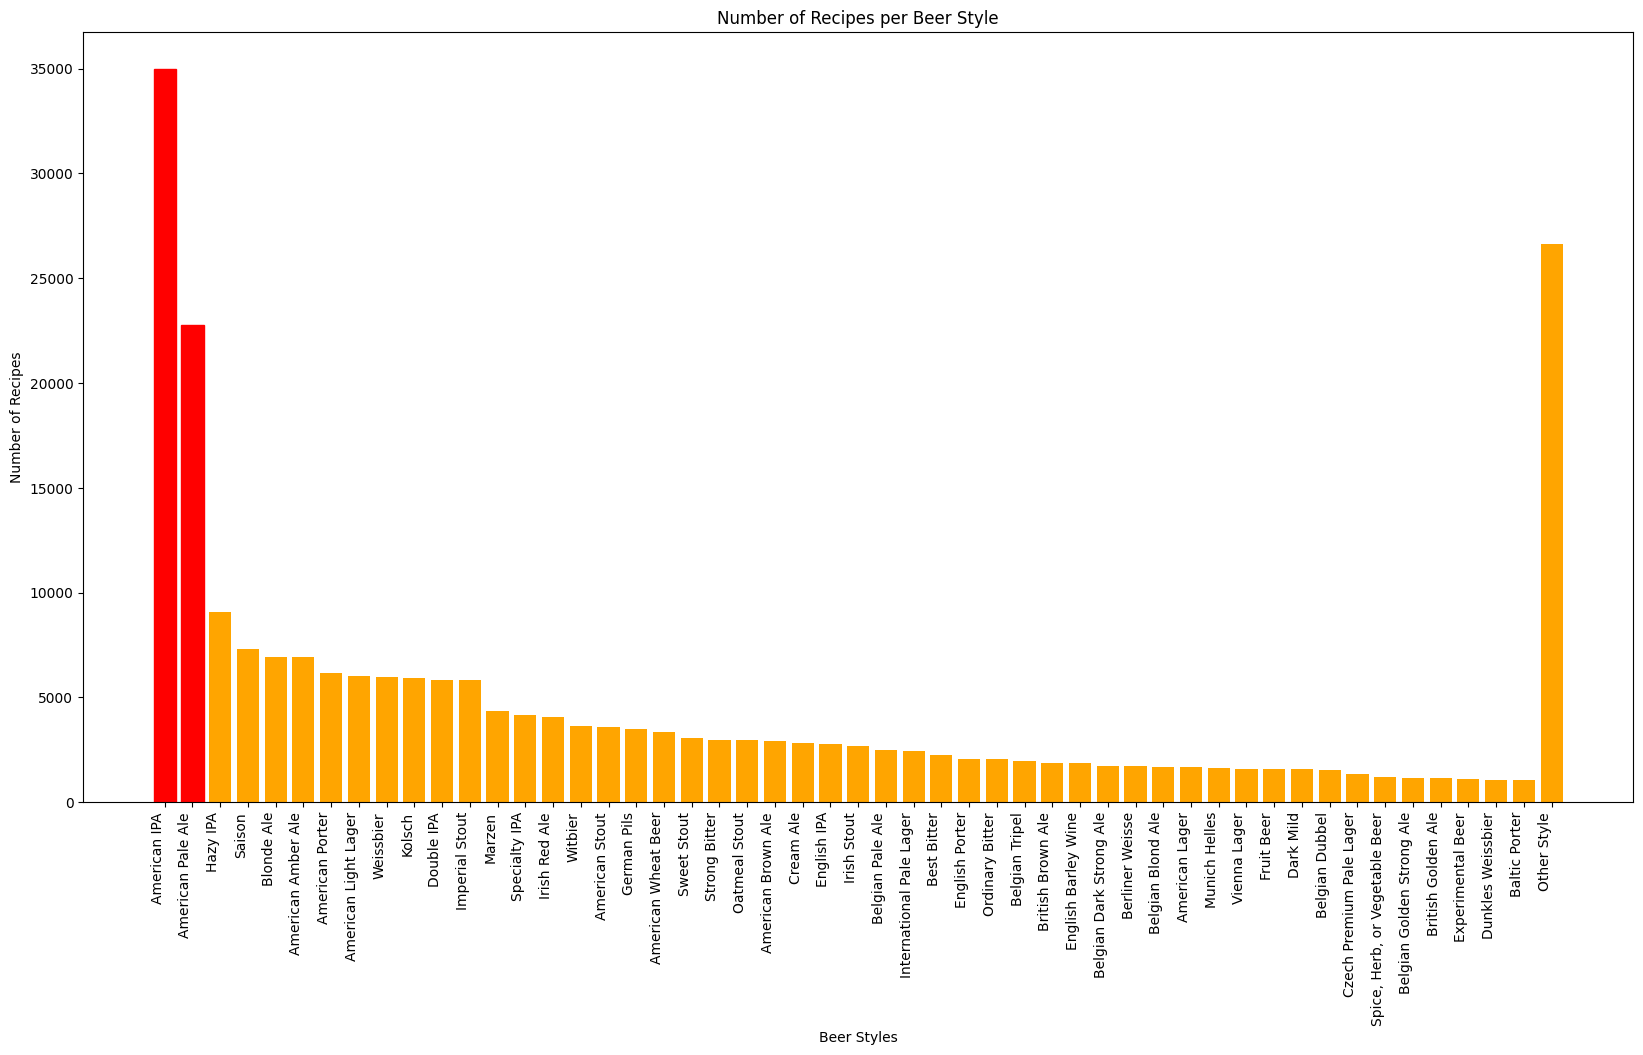

In [7]:
def total_occurrence_abbrev_v():
    # Group by 'Style' and count the number of occurrences
    style_counts = beer_recipes['Style'].value_counts()

    # Sort the data in descending order
    style_counts = style_counts.sort_values(ascending=False)

    # Group the first 50 styles and the rest into "Other Style"
    top_styles = style_counts[:50]
    other_styles = pd.Series([style_counts[50:].sum()], index=['Other Style'])
    style_counts = pd.concat([top_styles, other_styles])

    # Reverse order so largest values appear on the left
    # style_counts = style_counts[::-1]

    # Plot the bar chart vertically
    fig, ax = plt.subplots(figsize=(20, 10))
    bars = ax.bar(style_counts.index, style_counts.values, color='orange')  # type: ignore # Vertical bars

    # Highlight the top 2 bars
    bars[-50].set_color('red')  # Largest value (now at the left)
    bars[-51].set_color('red')

    # Formatting
    plt.ylabel('Number of Recipes')
    plt.xlabel('Beer Styles')
    plt.title('Number of Recipes per Beer Style')

    # Rotate x-axis labels for readability
    plt.xticks(rotation=90, ha='right')

    plt.show()

total_occurrence_abbrev_v()

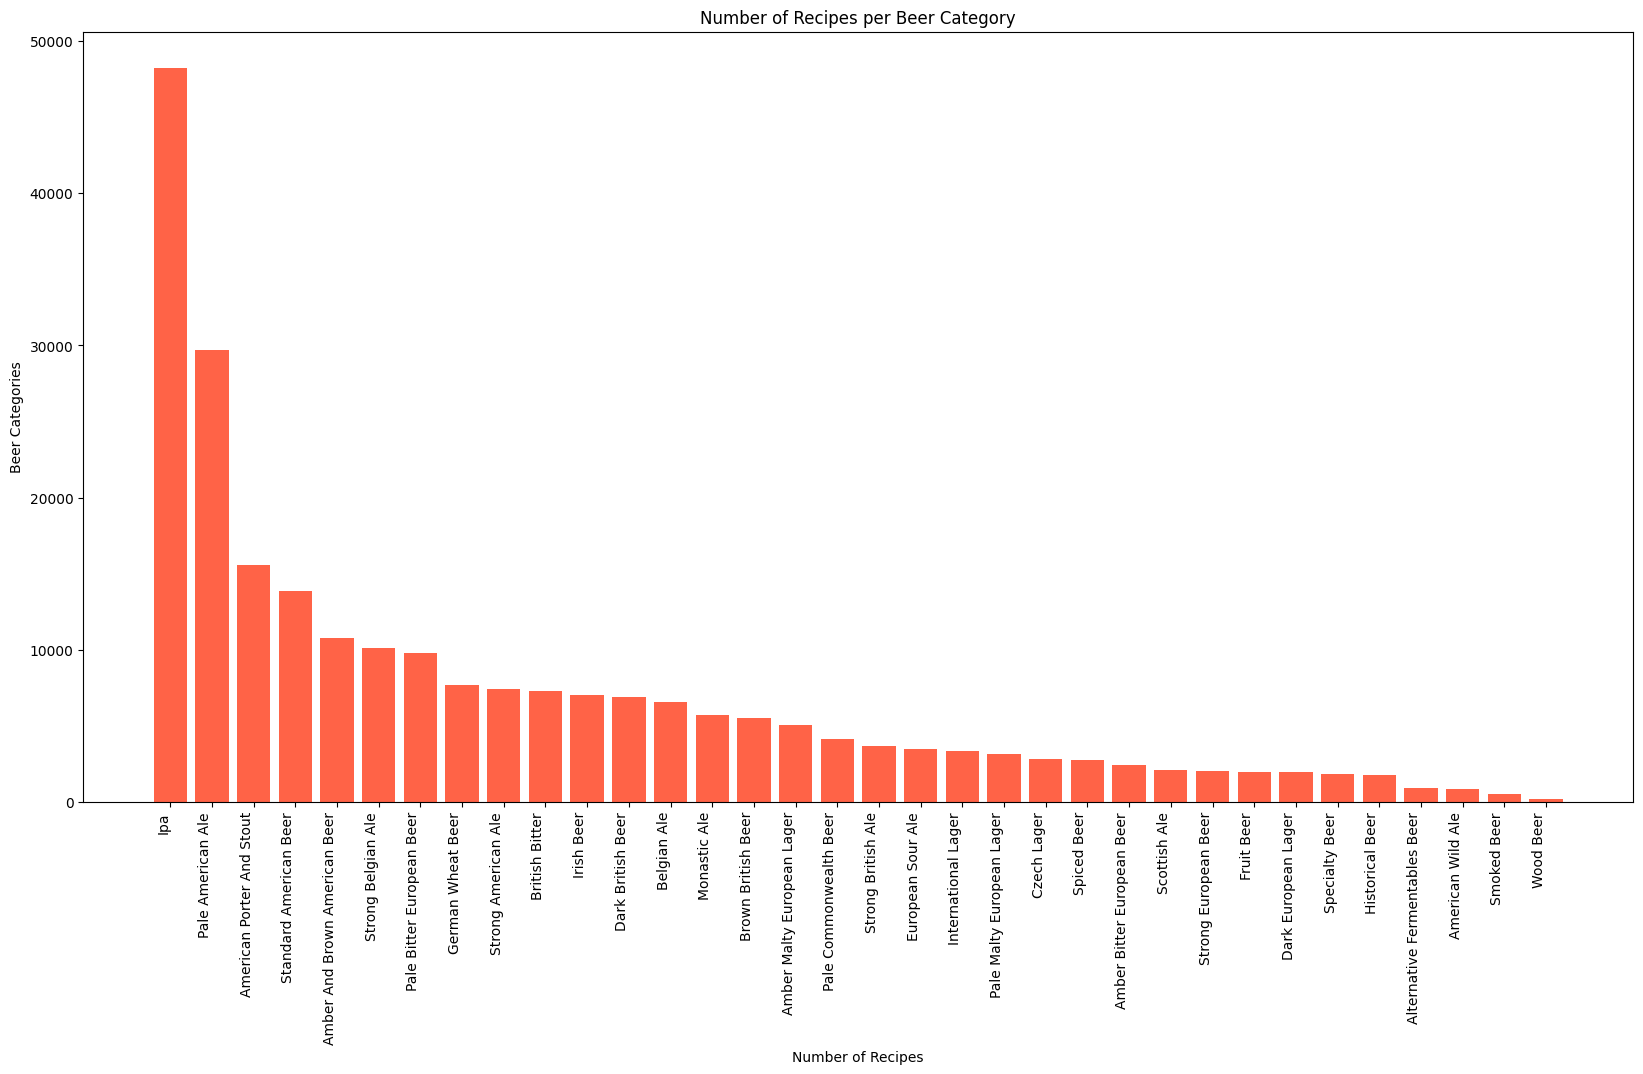

In [8]:
# Group by 'Category' and count the number of occurrences
category_counts = beer_recipes['Category'].value_counts()

# Sort the data in descending order
# category_counts = category_counts.sort_values(ascending=True)

# Plot the bar chart horizontally
fig, ax = plt.subplots(figsize=(20, 10))
bars = ax.bar(category_counts.index, category_counts.values, color='tomato')

plt.xlabel('Number of Recipes')
plt.ylabel('Beer Categories')
plt.title('Number of Recipes per Beer Category')

# Rotate x-axis labels for readability
plt.xticks(rotation=90, ha='right')
    
plt.show()

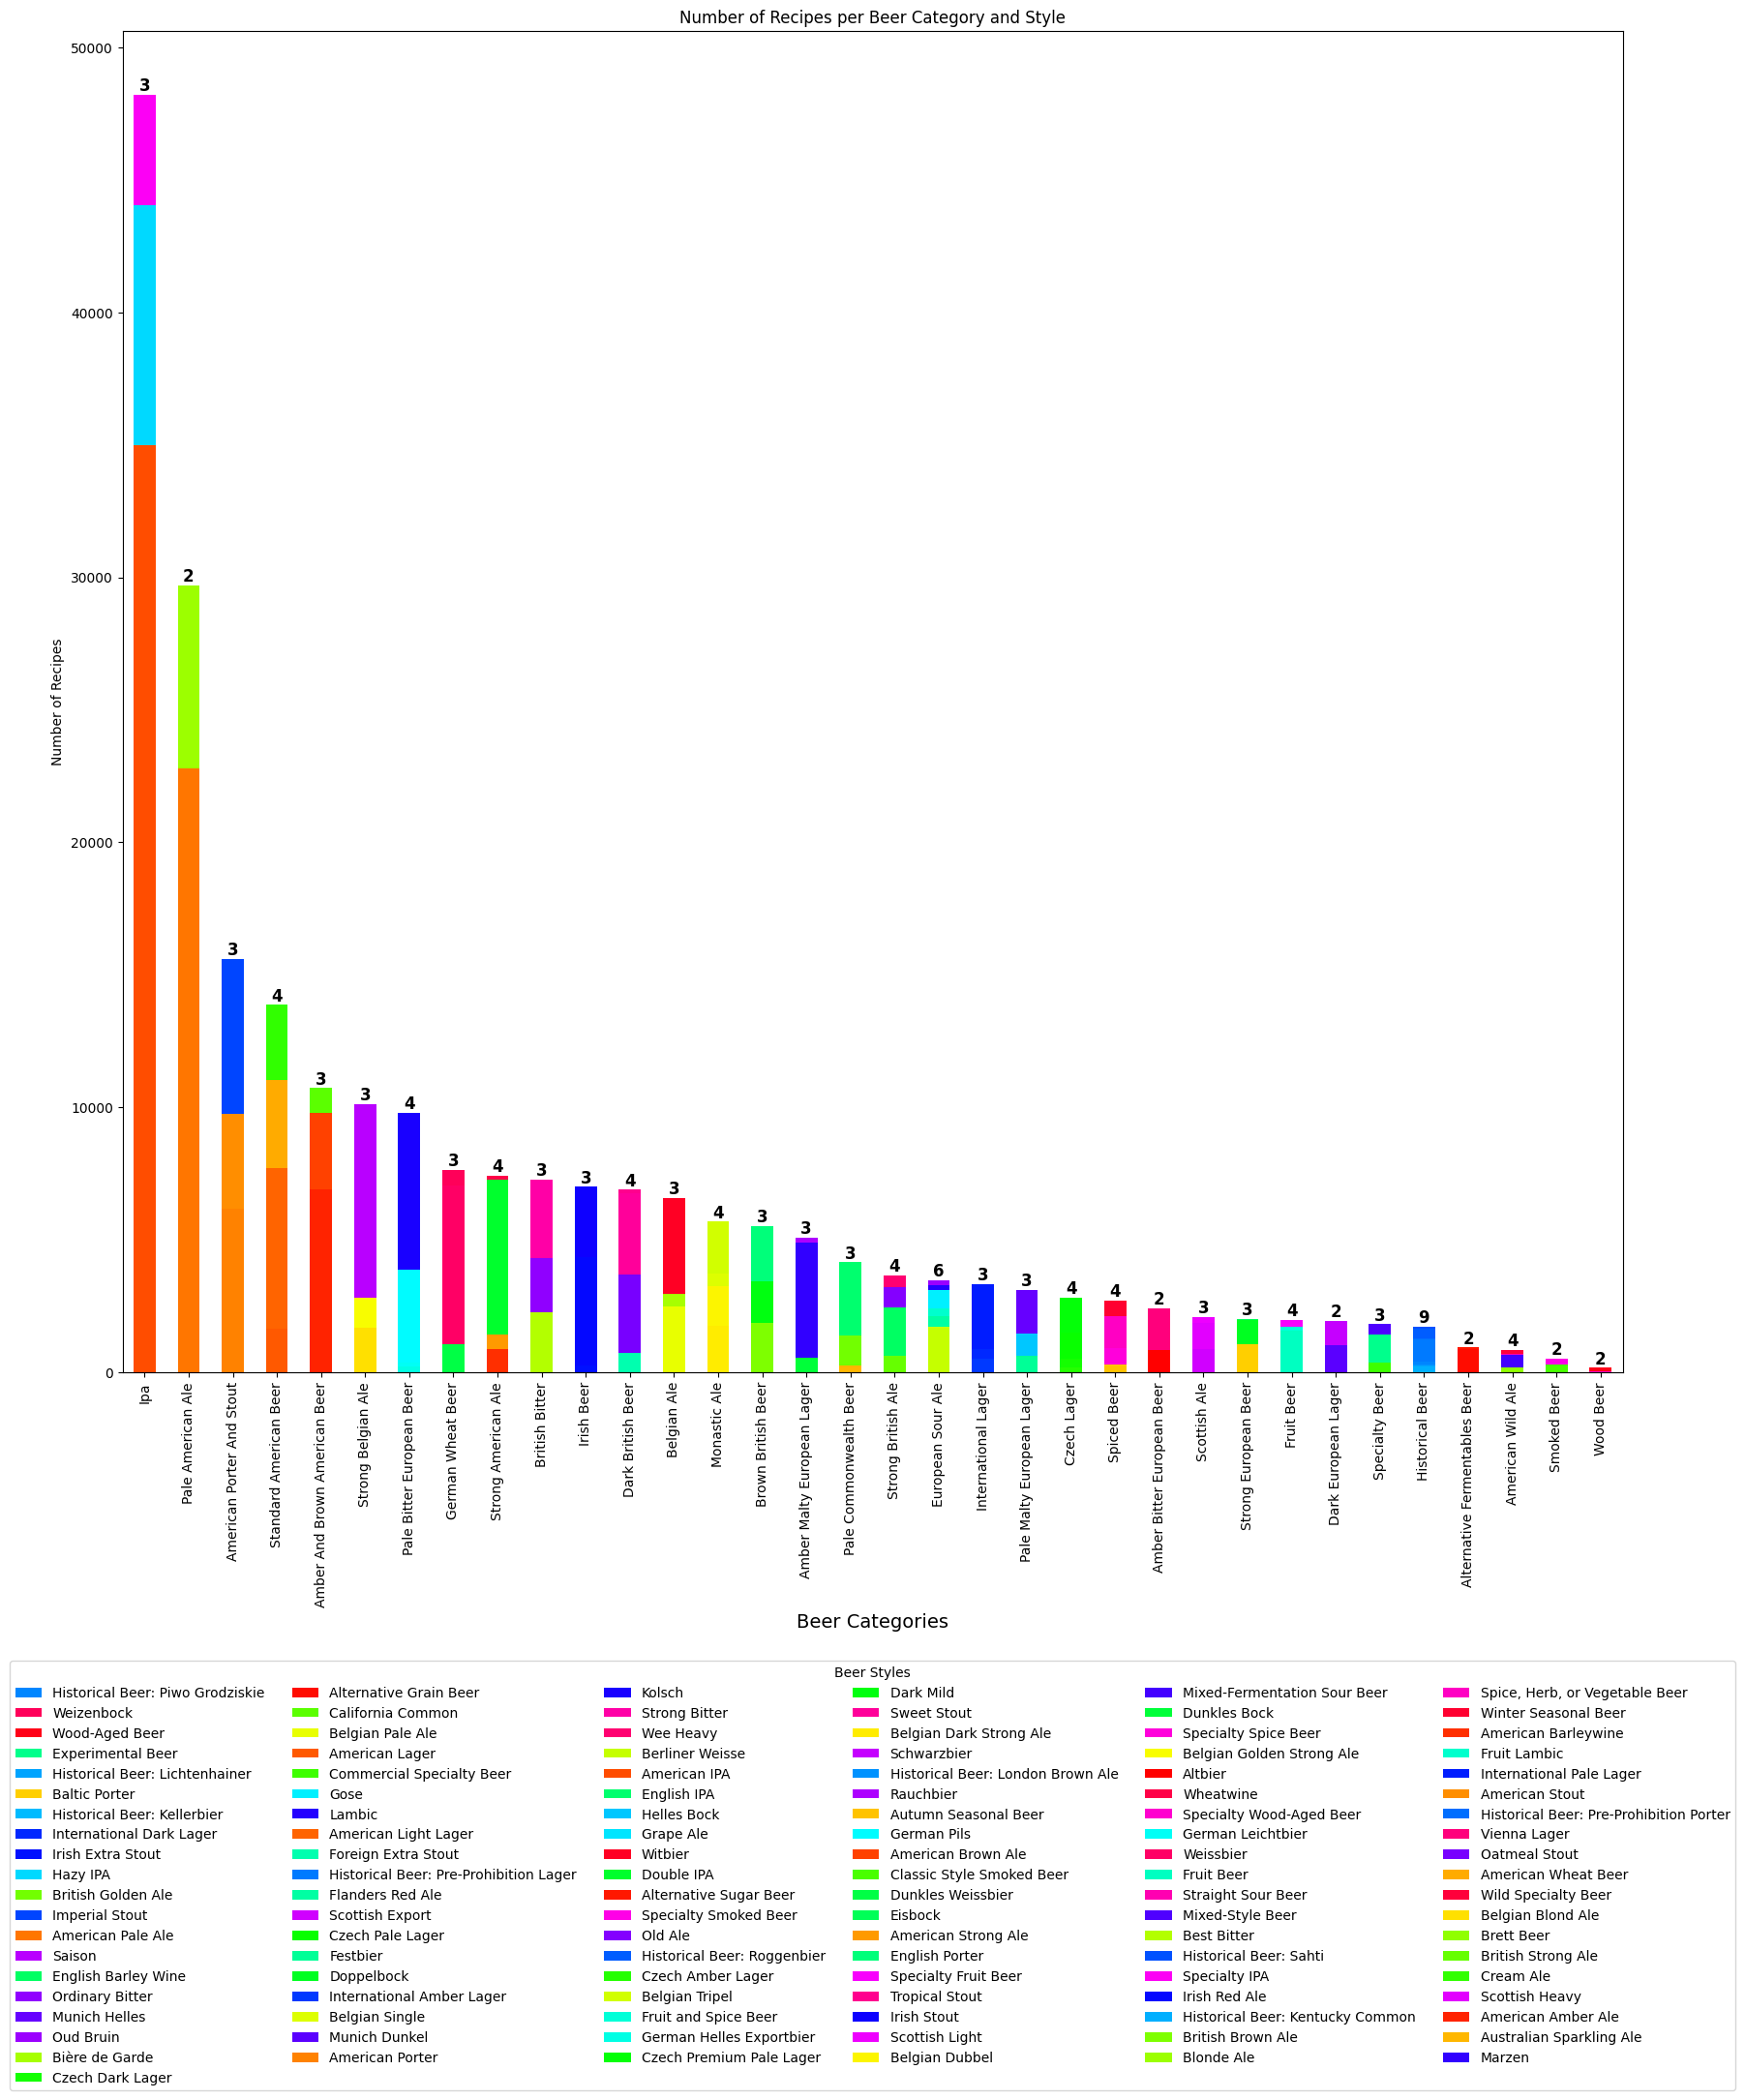

In [15]:
def stack_bar_category():
# Group by 'Category' and 'Style' and count the number of occurrences
    category_style_counts = beer_recipes.groupby(['Category', 'Style']).size().unstack().fillna(0)

# Sort categories by total count (largest first)
    category_style_counts = category_style_counts.loc[category_style_counts.sum(axis=1).sort_values(ascending=False).index]

# Shuffle the style order randomly for the legend
    random.seed(42)
    shuffled_styles = list(category_style_counts.columns)
    random.shuffle(shuffled_styles)

# Plot the stacked bar chart
    fig, ax = plt.subplots(figsize=(20, 18))
    category_style_counts.plot(kind='bar', stacked=True, ax=ax, colormap='hsv')

    plt.xlabel('Beer Categories', fontsize=14)
    plt.ylabel('Number of Recipes')
    plt.title('Number of Recipes per Beer Category and Style')

# Count unique styles per category
    unique_styles_per_category = beer_recipes.groupby('Category')['Style'].nunique()

# Add text annotations above bars
    for i, category in enumerate(category_style_counts.index):
        ax.text(i, category_style_counts.loc[category].sum(), f"{int(unique_styles_per_category.loc[category])}", ha='center', va='bottom', fontsize=12, fontweight='bold')

# Update legend with shuffled order
    handles, labels = ax.get_legend_handles_labels()
    shuffled_handles_labels = sorted(zip(handles, labels), key=lambda x: shuffled_styles.index(x[1]))
    handles, labels = zip(*shuffled_handles_labels)
    ax.legend(handles, labels, title='Beer Styles', bbox_to_anchor=(.5, -0.21), loc='upper center', ncol=6)

    plt.show()

stack_bar_category()